# 01 - Data Understanding

## Goal

The goal of this notebook is to understand the structure and quality of the Divar real-estate dataset before performing statistical analysis or machine learning.

We will inspect:

- Dataset dimensions
- Column names and data types
- Sample records
- Missing values
- Unique values
- Duplicate records
- Numerical distributions
- Potential data quality issues

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"

DIVAR_PATH = DATA_DIR / "Divar.csv"
CITY_PATH = DATA_DIR / "iran_city_classification.csv"

print("Project root:", PROJECT_ROOT)
print("Divar exists:", DIVAR_PATH.exists())
print("City classification exists:", CITY_PATH.exists())

Project root: /home/mm/Projects/ai-bootcamp-project
Divar exists: True
City classification exists: True


In [3]:
divar_size_mb = DIVAR_PATH.stat().st_size / (1024 ** 2)
city_size_mb = CITY_PATH.stat().st_size / (1024 ** 2)

print(f"Divar.csv: {divar_size_mb:.2f} MB")
print(f"iran_city_classification.csv: {city_size_mb:.2f} MB")

Divar.csv: 757.09 MB
iran_city_classification.csv: 0.01 MB


In [4]:
import pandas as pd
import numpy as np

In [5]:
sample = pd.read_csv(DIVAR_PATH, nrows=5)
sample

sample.columns.tolist()

['Unnamed: 0',
 'cat2_slug',
 'cat3_slug',
 'city_slug',
 'neighborhood_slug',
 'created_at_month',
 'user_type',
 'description',
 'title',
 'rent_mode',
 'rent_value',
 'rent_to_single',
 'rent_type',
 'price_mode',
 'price_value',
 'credit_mode',
 'credit_value',
 'rent_credit_transform',
 'transformable_price',
 'transformable_credit',
 'transformed_credit',
 'transformable_rent',
 'transformed_rent',
 'land_size',
 'building_size',
 'deed_type',
 'has_business_deed',
 'floor',
 'rooms_count',
 'total_floors_count',
 'unit_per_floor',
 'has_balcony',
 'has_elevator',
 'has_warehouse',
 'has_parking',
 'construction_year',
 'is_rebuilt',
 'has_water',
 'has_warm_water_provider',
 'has_electricity',
 'has_gas',
 'has_heating_system',
 'has_cooling_system',
 'has_restroom',
 'has_security_guard',
 'has_barbecue',
 'building_direction',
 'has_pool',
 'has_jacuzzi',
 'has_sauna',
 'floor_material',
 'property_type',
 'regular_person_capacity',
 'extra_person_capacity',
 'cost_per_extra_p

In [6]:
# Loading Data
df = pd.read_csv(DIVAR_PATH,
    low_memory=False)
city_df = pd.read_csv(CITY_PATH)

In [7]:
print("Divar shape:", df.shape)
print("City classification shape:", city_df.shape)

Divar shape: (1000000, 61)
City classification shape: (240, 2)


In [8]:
df.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.tail()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
999995,999995,residential-sell,apartment-sell,kermanshah,NaN,2024-07-01 00:00:00,مشاور املاک,~~~مشاورین املاک قبادی~~~\n■جنوبی تک واحدی\n■د...,آپارتمان ۱۸۰ متری وحدت غربی,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.350235,47.083241,500.0
999996,999996,residential-rent,apartment-rent,tehran,darya,2024-07-01 00:00:00,مشاور املاک,نوساز \n\n تک واحدی\n\nشخصی ساز\n\nروف گا...,آپارتمان ۱۱۰ متری سعادت آباد دریا,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.770454,51.369099,500.0
999997,999997,residential-sell,house-villa-sell,yazd,NaN,2024-11-01 00:00:00,NaN,سلام ودرود\nفروش منزل مسکونی واقع در خیابان ان...,منزل فروشی. خیابان انقلاب نرسیده به کارخانه...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999998,999998,temporary-rent,suite-apartment,bandar-anzali,NaN,2024-09-01 00:00:00,NaN,سویت بدون خواب (روبه دریا و معمولی)\nسویت ۱خوا...,مجتمع ویلایی کنار ساحل پاسداران,NaN,...,NaN,5.0,5.0,NaN,3000000.0,NaN,NaN,37.483501,49.438721,NaN
999999,999999,residential-rent,apartment-rent,tehran,jeyhoun,2024-08-01 00:00:00,مشاور املاک,⚜️املاک بزرگ میلیارد⚜️\n✅️۴۰ متر یک خواب\n✅️نو...,۴۰ متر/ یک خواب /فول بازسازی,مجانی,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.680767,51.365299,500.0


In [10]:
df.sample(5, random_state=42)

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
987231,987231,commercial-rent,shop-rent,tehran,kooy-e-bimeh,2024-05-01 00:00:00,مشاور املاک,✔مناسب مشاغل پروتئنی و دفتر بیمه و لبنیات \n...,مغازه ۳۶ متر بر خیابان بیمه(املاک ناظمی),مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
79954,79954,residential-sell,apartment-sell,urmia,NaN,2024-11-01 00:00:00,NaN,با سلام خدمت هشهریان عزیز\n\nواحد دومین قطعه ا...,فروش اپارتمان کلید نخورده مافی,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.514000,45.050632,NaN
567130,567130,commercial-rent,office-rent,tehran,niavaran,2024-07-01 00:00:00,مشاور املاک,۱۳۵ متر واحد لوکس به همراه تراس قابل چیدمان \n...,واحد سند اداری ۱۳۵ متر تاپ لوکیشن اقدسیه,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
500891,500891,residential-sell,apartment-sell,andisheh-new-town,NaN,2024-12-01 00:00:00,NaN,⚜️⚜️⚜️املاک بزرگ باور⚜️⚜️⚜️\n\n56 متر غرق در ن...,56متر*بدون مشابه*سندتکبرگ*وامدار,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.604279,50.756332,0.0
55399,55399,temporary-rent,villa,behbahan,NaN,2024-12-01 00:00:00,NaN,سلام درود همشهریان و مهمان های عزیز با ما با ب...,اجاره بهترین ویلا باغ ها,NaN,...,NaN,4.0,8,NaN,NaN,NaN,NaN,30.623905,50.287186,NaN


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  str    
 2   cat3_slug                   999999 non-null   str    
 3   city_slug                   999998 non-null   str    
 4   neighborhood_slug           437139 non-null   str    
 5   created_at_month            1000000 non-null  str    
 6   user_type                   288882 non-null   str    
 7   description                 1000000 non-null  str    
 8   title                       999946 non-null   str    
 9   rent_mode                   352994 non-null   str    
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   str    
 13  price_mod

In [12]:
missing = (df.isna()
      .sum().to_frame("missing_count"))

missing["missing_percent"] = (
    missing["missing_count"] / len(df) * 100)

missing = missing.sort_values(
    "missing_percent",ascending=False)

missing.head(30)

,missing_count,missing_percent
rent_to_single,999981,99.9981
cost_per_extra_person,989759,98.9759
rent_price_on_special_days,989537,98.9537
rent_price_at_weekends,986449,98.6449
rent_price_on_regular_days,981932,98.1932
extra_person_capacity,975991,97.5991
property_type,972943,97.2943
has_sauna,971521,97.1521
has_jacuzzi,971272,97.1272
has_pool,970610,97.0610


In [13]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round(duplicate_count / len(df) * 100, 2),
    "%")

Duplicate rows: 0
Duplicate percentage: 0.0 %


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000000.0,4.999995e+05,2.886753e+05,0.000000,2.499998e+05,4.999995e+05,7.499992e+05,9.999990e+05
rent_value,351322.0,4.102299e+10,3.807534e+12,0.000000,1.111110e+05,5.000000e+06,1.200000e+07,1.000000e+15
price_value,568346.0,1.736537e+10,5.878739e+11,0.000000,1.400000e+09,2.840000e+09,5.900000e+09,1.000000e+14
credit_value,352095.0,4.872084e+10,4.341346e+12,0.000000,1.000000e+08,2.500000e+08,5.000000e+08,1.000000e+15
transformable_credit,352085.0,4.872222e+10,4.341407e+12,0.000000,1.000000e+08,2.500000e+08,5.000000e+08,1.000000e+15
transformed_credit,72409.0,8.557025e+09,2.064576e+12,0.000000,2.000000e+08,4.000000e+08,8.500000e+08,5.555556e+14
transformable_rent,351248.0,4.103164e+10,3.807935e+12,0.000000,1.111110e+05,5.000000e+06,1.200000e+07,1.000000e+15
transformed_rent,72409.0,1.619934e+07,5.217890e+07,0.000000,1.000000e+06,6.000000e+06,1.500000e+07,3.000000e+09
land_size,186396.0,4.165480e+03,1.218927e+05,1.000000,1.100000e+02,1.950000e+02,2.800000e+02,1.000000e+07
building_size,980394.0,4.440648e+03,1.367118e+05,1.000000,7.500000e+01,1.030000e+02,1.650000e+02,1.000000e+07


In [15]:
df.describe()

,Unnamed: 0,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,1000000.000000,3.513220e+05,5.683460e+05,3.520950e+05,3.520850e+05,7.240900e+04,3.512480e+05,7.240900e+04,1.863960e+05,9.803940e+05,29870.000000,1.024100e+04,1.806800e+04,1.046300e+04,1.355100e+04,655608.000000,655608.000000,339699.000000
mean,499999.500000,4.102299e+10,1.736537e+10,4.872084e+10,4.872222e+10,8.557025e+09,4.103164e+10,1.619934e+07,4.165480e+03,4.440648e+03,6.557650,1.209785e+10,1.389016e+11,2.355548e+10,3.156551e+10,34.982108,51.629743,465.149147
std,288675.278932,3.807534e+12,5.878739e+11,4.341346e+12,4.341407e+12,2.064576e+12,3.807935e+12,5.217890e+07,1.218927e+05,1.367118e+05,7.698655,1.103482e+12,7.042335e+12,1.542049e+12,2.434942e+12,2.379169,3.160920,125.896250
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.162369,0.000000
25%,249999.750000,1.111110e+05,1.400000e+09,1.000000e+08,1.000000e+08,2.000000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,3.000000,5.000000e+04,4.000000e+05,6.000000e+05,5.500000e+05,34.553551,50.677175,500.000000
50%,499999.500000,5.000000e+06,2.840000e+09,2.500000e+08,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06,1.950000e+02,1.030000e+02,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.100000e+06,35.723312,51.345791,500.000000
75%,749999.250000,1.200000e+07,5.900000e+09,5.000000e+08,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07,2.800000e+02,1.650000e+02,7.000000,2.000000e+05,1.600000e+06,2.500000e+06,2.500000e+06,36.307013,51.805291,500.000000
max,999999.000000,1.000000e+15,1.000000e+14,1.000000e+15,1.000000e+15,5.555556e+14,1.000000e+15,3.000000e+09,1.000000e+07,1.000000e+07,50.000000,1.111111e+14,5.006007e+14,1.111111e+14,2.002503e+14,40.358055,74.511620,500.000000


In [16]:
unique_counts = (
    df.nunique(dropna=False)
      .sort_values(ascending=False)
      .to_frame("unique_count"))

unique_counts

,unique_count
Unnamed: 0,1000000
description,989449
title,904093
location_longitude,429432
location_latitude,387489
...,...
has_gas,3
has_sauna,3
has_barbecue,3
has_pool,3


## Column-level Data Audit

In this section, we inspect each column in terms of data type,
missing values, and cardinality to identify potential data quality
issues before cleaning or analysis.

In [17]:
column_audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "unique_count": df.nunique(dropna=False)
})

column_audit.sort_values("missing_percent", ascending=False)

,dtype,non_null_count,missing_count,missing_percent,unique_count
rent_to_single,object,19,999981,99.9981,3
cost_per_extra_person,float64,10241,989759,98.9759,219
rent_price_on_special_days,float64,10463,989537,98.9537,380
rent_price_at_weekends,float64,13551,986449,98.6449,417
rent_price_on_regular_days,float64,18068,981932,98.1932,501
...,...,...,...,...,...
cat3_slug,str,999999,1,0.0001,17
cat2_slug,str,1000000,0,0.0000,6
Unnamed: 0,int64,1000000,0,0.0000,1000000
description,str,1000000,0,0.0000,989449


In [18]:
df["cat3_slug"].value_counts(dropna=False)

cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
NaN                                        1
Name: count, dtype: int64

In [19]:
category_price_profile = (
    df.groupby("cat3_slug", dropna=False)
      .agg(
          total_ads=("cat3_slug", "size"),
          price_count=("price_value", "count"),
          median_price=("price_value", "median"),
          mean_price=("price_value", "mean")
      )
      .sort_values("total_ads", ascending=False)
)

category_price_profile

,total_ads,price_count,median_price,mean_price
cat3_slug,,,,
apartment-sell,303385,303380,3.300000e+09,1.549611e+10
apartment-rent,211880,4,2.550000e+08,1.015050e+09
plot-old,133570,109836,1.350000e+09,2.243806e+10
house-villa-sell,121753,121748,2.700000e+09,1.538754e+10
house-villa-rent,64678,2,6.055555e+05,6.055555e+05
shop-rent,45993,23,1.350000e+08,2.658700e+08
shop-sell,21855,18559,3.200000e+09,2.912003e+10
office-rent,21418,6,6.090000e+07,2.616006e+08
suite-apartment,16465,2,1.240000e+06,1.240000e+06


In [20]:
category_price_profile["price_available_percent"] = (
    category_price_profile["price_count"]
    / category_price_profile["total_ads"]
    * 100
)

category_price_profile

,total_ads,price_count,median_price,mean_price,price_available_percent
cat3_slug,,,,,
apartment-sell,303385,303380,3.300000e+09,1.549611e+10,99.998352
apartment-rent,211880,4,2.550000e+08,1.015050e+09,0.001888
plot-old,133570,109836,1.350000e+09,2.243806e+10,82.231040
house-villa-sell,121753,121748,2.700000e+09,1.538754e+10,99.995893
house-villa-rent,64678,2,6.055555e+05,6.055555e+05,0.003092
shop-rent,45993,23,1.350000e+08,2.658700e+08,0.050008
shop-sell,21855,18559,3.200000e+09,2.912003e+10,84.918783
office-rent,21418,6,6.090000e+07,2.616006e+08,0.028014
suite-apartment,16465,2,1.240000e+06,1.240000e+06,0.012147


In [21]:
created_dates = pd.to_datetime(
    df["created_at_month"],
    errors="coerce"
)

print("Earliest date:", created_dates.min())
print("Latest date:", created_dates.max())
print("Invalid dates:", created_dates.isna().sum())

Earliest date: 2020-02-01 00:00:00
Latest date: 2025-03-01 00:00:00
Invalid dates: 0


In [22]:
created_dates.dt.year.value_counts().sort_index()

created_at_month
2020         2
2021         6
2022        65
2023      1689
2024    996946
2025      1292
Name: count, dtype: int64

In [23]:
created_dates.dt.to_period("M").value_counts().sort_index()

created_at_month
2020-02         1
2020-12         1
2021-02         1
2021-05         1
2021-06         1
2021-11         1
2021-12         2
2022-01         1
2022-02         2
2022-03         1
2022-04         5
2022-05         7
2022-06         4
2022-07         4
2022-08         9
2022-09         6
2022-10         6
2022-11         9
2022-12        11
2023-01        17
2023-02        17
2023-03        25
2023-04        23
2023-05        53
2023-06        66
2023-07        96
2023-08       117
2023-09       177
2023-10       213
2023-11       353
2023-12       532
2024-01       942
2024-02      1211
2024-03      1881
2024-04      7187
2024-05    108759
2024-06    125624
2024-07    133219
2024-08    132396
2024-09    121432
2024-10    126387
2024-11    121456
2024-12    116452
2025-01      1139
2025-02       148
2025-03         5
Freq: M, Name: count, dtype: int64

In [24]:
clustering_candidates = [
    "location_latitude",
    "location_longitude",
    "transformable_price",
    "building_size",
    "rooms_count"
]


In [25]:
df[clustering_candidates].describe().T  

,count,mean,std,min,25%,50%,75%,max
location_latitude,655608.0,34.982108,2.379169,23.626478,34.553551,35.723312,36.307013,4.035806e+01
location_longitude,655608.0,51.629743,3.160920,40.162369,50.677175,51.345791,51.805291,7.451162e+01
building_size,980394.0,4440.648064,136711.844395,1.000000,75.000000,103.000000,165.000000,1.000000e+07


In [26]:
df[clustering_candidates].isna().mean().mul(100)

location_latitude      34.4392
location_longitude     34.4392
transformable_price    64.7106
building_size           1.9606
rooms_count            15.4101
dtype: float64

In [27]:
df[clustering_candidates].notna().all(axis=1).sum()

np.int64(234829)

## Inspection of Potential Numeric Features

Some features that are conceptually numerical are currently stored as
object/string data types. Before performing any conversion, we inspect
their actual values and determine why Pandas has not recognized them
as numerical features.

In [28]:
df["rooms_count"].value_counts(dropna=False).head(30)

rooms_count
دو              404050
یک              192083
NaN             154101
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

In [29]:
df["transformable_price"].value_counts(dropna=False).head(30)

transformable_price
NaN      647106
False    279778
True      73116
Name: count, dtype: int64

In [30]:
print(df["rooms_count"].map(type).value_counts())
print()
print(df["transformable_price"].map(type).value_counts())

rooms_count
<class 'str'>      845899
<class 'float'>    154101
Name: count, dtype: int64

transformable_price
<class 'float'>    647106
<class 'bool'>     352894
Name: count, dtype: int64


In [31]:
rooms_numeric = pd.to_numeric(
    df["rooms_count"],
    errors="coerce"
)

price_numeric = pd.to_numeric(
    df["transformable_price"],
    errors="coerce"
)

print(
    "rooms_count non-null before:",
    df["rooms_count"].notna().sum()
)

print(
    "rooms_count numeric after conversion:",
    rooms_numeric.notna().sum()
)

print()

print(
    "transformable_price non-null before:",
    df["transformable_price"].notna().sum()
)

print(
    "transformable_price numeric after conversion:",
    price_numeric.notna().sum()
)

rooms_count non-null before: 845899
rooms_count numeric after conversion: 0

transformable_price non-null before: 352894
transformable_price numeric after conversion: 352894


In [32]:
invalid_rooms = df.loc[
    df["rooms_count"].notna() &
    rooms_numeric.isna(),
    "rooms_count"
].value_counts()

invalid_rooms.head(30)

rooms_count
دو              404050
یک              192083
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

In [33]:
invalid_prices = df.loc[
    df["transformable_price"].notna() &
    price_numeric.isna(),
    "transformable_price"
].value_counts()

invalid_prices.head(30)

Series([], Name: count, dtype: int64)

## Inspection of Financial Features

The dataset contains multiple variables related to sale price,
rent, credit, and transformed financial values. Before selecting
a price feature for analysis or clustering, we inspect the meaning
and relationship between these variables.

In [34]:
financial_columns = [
    "cat2_slug",
    "cat3_slug",
    "rent_value",
    "price_value",
    "credit_value",
    "rent_credit_transform",
    "transformable_price",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent"
]

df[financial_columns].sample(20, random_state=42)

,cat2_slug,cat3_slug,rent_value,price_value,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent
987231,commercial-rent,shop-rent,28000000.0,NaN,3.000000e+08,False,False,3.000000e+08,NaN,28000000.0,NaN
79954,residential-sell,apartment-sell,NaN,3.350000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
567130,commercial-rent,office-rent,60000000.0,NaN,3.000000e+09,True,True,3.000000e+09,5.000000e+09,60000000.0,0.0
500891,residential-sell,apartment-sell,NaN,1.250000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55399,temporary-rent,villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
135049,residential-sell,apartment-sell,NaN,9.900000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
733378,residential-rent,apartment-rent,0.0,NaN,1.800000e+09,False,False,1.800000e+09,NaN,0.0,NaN
732057,residential-rent,apartment-rent,14200000.0,NaN,2.000000e+08,False,False,2.000000e+08,NaN,14200000.0,NaN
51333,residential-rent,house-villa-rent,8000000.0,NaN,4.000000e+08,False,False,4.000000e+08,NaN,8000000.0,NaN
731479,residential-rent,apartment-rent,13000000.0,NaN,2.300000e+08,False,False,2.300000e+08,NaN,13000000.0,NaN


In [35]:
df[[
    "rent_credit_transform",
    "transformable_price"
]].apply(
    lambda col: col.value_counts(dropna=False)
)

,rent_credit_transform,transformable_price
NaN,647015,647106
False,326561,279778
True,26424,73116


In [36]:
financial_numeric = [
    "rent_value",
    "price_value",
    "credit_value",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent"
]

df[financial_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
rent_value,351322.0,4.102299e+10,3.807534e+12,0.0,1.111110e+05,5.000000e+06,1.200000e+07,1.000000e+15
price_value,568346.0,1.736537e+10,5.878739e+11,0.0,1.400000e+09,2.840000e+09,5.900000e+09,1.000000e+14
credit_value,352095.0,4.872084e+10,4.341346e+12,0.0,1.000000e+08,2.500000e+08,5.000000e+08,1.000000e+15
transformable_credit,352085.0,4.872222e+10,4.341407e+12,0.0,1.000000e+08,2.500000e+08,5.000000e+08,1.000000e+15
transformed_credit,72409.0,8.557025e+09,2.064576e+12,0.0,2.000000e+08,4.000000e+08,8.500000e+08,5.555556e+14
transformable_rent,351248.0,4.103164e+10,3.807935e+12,0.0,1.111110e+05,5.000000e+06,1.200000e+07,1.000000e+15
transformed_rent,72409.0,1.619934e+07,5.217890e+07,0.0,1.000000e+06,6.000000e+06,1.500000e+07,3.000000e+09


In [37]:
clustering_candidates = [
    "location_latitude",
    "location_longitude",
    "transformable_price",
    "building_size",
    "rooms_count"
]

**Observation:** `transformable_price` was initially considered as a
continuous price feature. Inspection showed that it is actually a
boolean variable (`True`/`False`), so it should not be interpreted
as a monetary value. The appropriate financial feature for clustering
will be determined after inspecting the financial variables.

In [38]:
q4_df = df[
    df["price_value"].notna() &
    (df["price_value"] > 0)
].copy()

q4_df.shape

(566444, 61)

In [39]:
q4_df["cat3_slug"].value_counts()

cat3_slug
apartment-sell                        302642
house-villa-sell                      120783
plot-old                              109836
shop-sell                              18445
industry-agriculture-business-sell      9029
office-sell                             4455
presell                                 1203
shop-rent                                 23
office-rent                                6
partnership                                6
industry-agriculture-business-rent         5
apartment-rent                             4
house-villa-rent                           2
suite-apartment                            2
workspace                                  2
villa                                      1
Name: count, dtype: int64

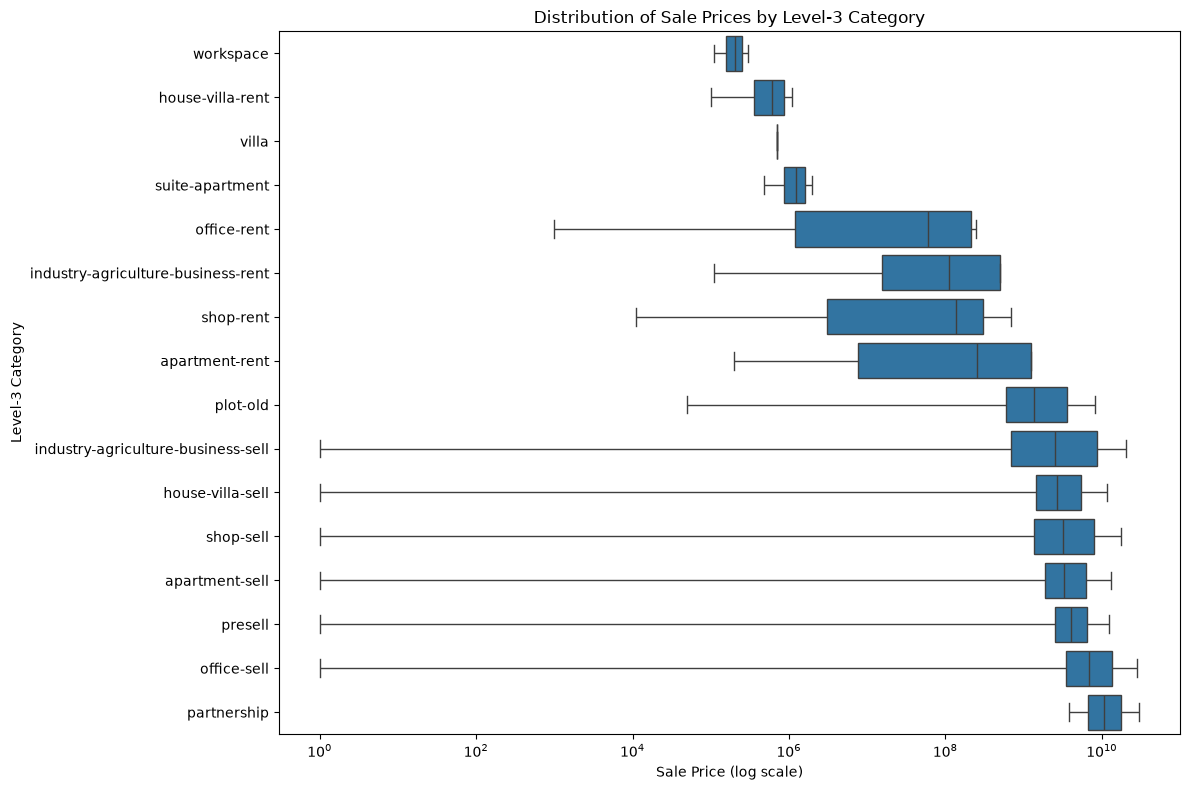

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

order = (
    q4_df.groupby("cat3_slug")["price_value"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=q4_df,
    x="price_value",
    y="cat3_slug",
    order=order,
    showfliers=False
)

plt.xscale("log")

plt.title("Distribution of Sale Prices by Level-3 Category")
plt.xlabel("Sale Price (log scale)")
plt.ylabel("Level-3 Category")

plt.tight_layout()
plt.show()

In [41]:
q4_summary = (
    q4_df.groupby("cat3_slug")["price_value"]
    .agg(
        count="count",
        median="median",
        mean="mean"
    )
    .sort_values("median", ascending=False)
)

q4_summary

,count,median,mean
cat3_slug,,,
partnership,6,1.055556e+10,1.340185e+10
office-sell,4455,6.800000e+09,2.544401e+10
presell,1203,4.000000e+09,6.723954e+09
apartment-sell,302642,3.300000e+09,1.553390e+10
shop-sell,18445,3.200000e+09,2.930001e+10
house-villa-sell,120783,2.700000e+09,1.551048e+10
industry-agriculture-business-sell,9029,2.500000e+09,1.865589e+10
plot-old,109836,1.350000e+09,2.243806e+10
apartment-rent,4,2.550000e+08,1.015050e+09


## Q7

In [42]:
q7_df = df[
    df["price_value"].notna() &
    (df["price_value"] > 0)
].copy()

q7_df["date"] = pd.to_datetime(
    q7_df["created_at_month"],
    errors="coerce"
)

q7_df["jalali_year"] = np.where(
    q7_df["date"].dt.month >= 4,
    q7_df["date"].dt.year - 621,
    q7_df["date"].dt.year - 622
)

In [43]:
q7_df = q7_df[
    q7_df["jalali_year"].between(1400, 1403)
]

In [44]:
q7_df["jalali_year"].value_counts().sort_index()

jalali_year
1400         3
1401        47
1402      4090
1403    562303
Name: count, dtype: int64

In [45]:
yearly_price = (
    q7_df.groupby("jalali_year")
    .agg(
        count=("price_value", "count"),
        nominal_mean_price=("price_value", "mean")
    )
)

yearly_price

,count,nominal_mean_price
jalali_year,,
1400,3,1.066667e+09
1401,47,1.922092e+10
1402,4090,7.928597e+09
1403,562303,1.749266e+10


In [46]:
cpi = {
    1400: 100,
    1401: 100 * 1.4575,
}

cpi[1402] = cpi[1401] * 1.4069
cpi[1403] = cpi[1402] * 1.325

cpi

{1400: 100, 1401: 145.75, 1402: 205.055675, 1403: 271.698769375}

In [47]:
yearly_price["cpi"] = yearly_price.index.map(cpi)

yearly_price["real_mean_price"] = (
    yearly_price["nominal_mean_price"]
    * 100
    / yearly_price["cpi"]
)

yearly_price

,count,nominal_mean_price,cpi,real_mean_price
jalali_year,,,,
1400,3,1.066667e+09,100.000000,1.066667e+09
1401,47,1.922092e+10,145.750000,1.318760e+10
1402,4090,7.928597e+09,205.055675,3.866558e+09
1403,562303,1.749266e+10,271.698769,6.438256e+09


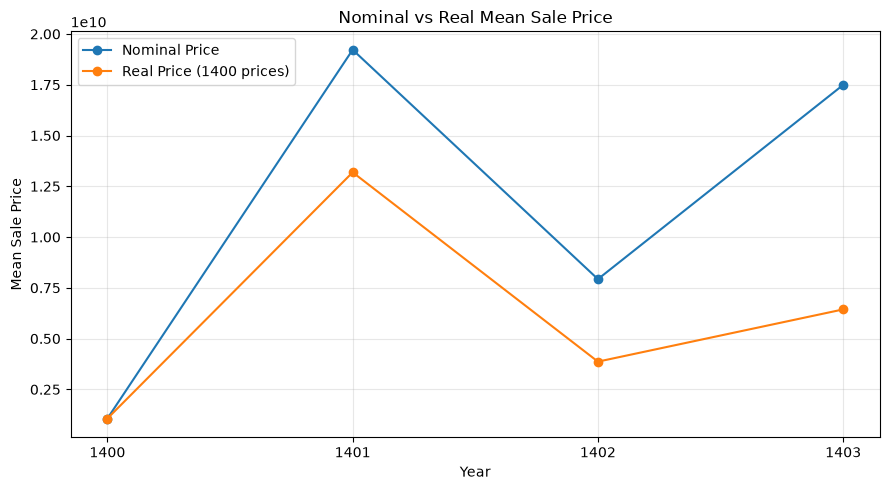

In [48]:
plot_df = yearly_price.reset_index()

plt.figure(figsize=(9, 5))

plt.plot(
    plot_df["jalali_year"],
    plot_df["nominal_mean_price"],
    marker="o",
    label="Nominal Price"
)

plt.plot(
    plot_df["jalali_year"],
    plot_df["real_mean_price"],
    marker="o",
    label="Real Price (1400 prices)"
)

plt.xticks([1400, 1401, 1402, 1403])

plt.xlabel("Year")
plt.ylabel("Mean Sale Price")
plt.title("Nominal vs Real Mean Sale Price")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Clustering

In [49]:
rooms_mapping = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5
}

df["rooms_numeric"] = df["rooms_count"].map(rooms_mapping)

In [50]:
cluster_df = df[
    df["price_value"].notna() &
    (df["price_value"] > 0) &
    df["location_latitude"].notna() &
    df["location_longitude"].notna() &
    df["building_size"].notna() &
    df["rooms_numeric"].notna()
].copy()

print(cluster_df.shape)

(299679, 62)


In [51]:
cluster_df = cluster_df[cluster_df["building_size"] > 0].copy()

cluster_df["log_price"] = np.log1p(cluster_df["price_value"])
cluster_df["log_building_size"] = np.log1p(cluster_df["building_size"])

In [52]:
sample_size = min(50000, len(cluster_df))

cluster_sample = cluster_df.sample(
    n=sample_size,
    random_state=42
).copy()

In [53]:
features = [
    "location_latitude",
    "location_longitude",
    "log_price",
    "log_building_size",
    "rooms_numeric"
]

X = cluster_sample[features]

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [55]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

cluster_sample["cluster"] = kmeans.fit_predict(X_scaled)

In [56]:
cluster_sample["cluster"].value_counts().sort_index()

cluster
0    15702
1     4959
2      687
3     3603
4     3952
5     1021
6     3240
7     9353
8     1686
9     5797
Name: count, dtype: int64

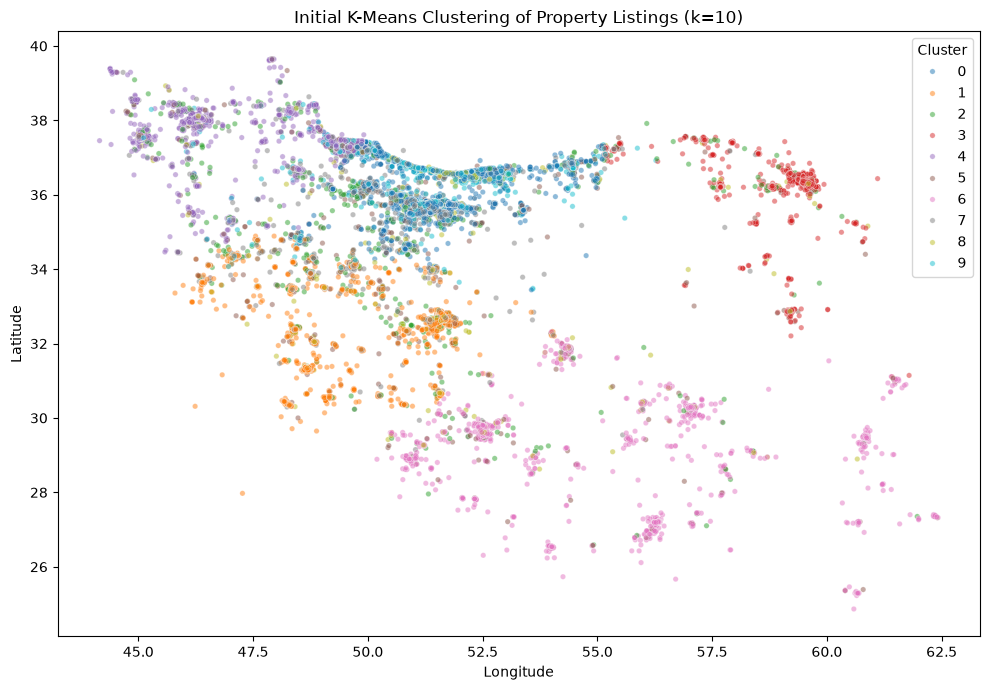

In [57]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=cluster_sample,
    x="location_longitude",
    y="location_latitude",
    hue="cluster",
    palette="tab10",
    s=15,
    alpha=0.5,
    legend="full"
)

plt.title("Initial K-Means Clustering of Property Listings (k=10)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [58]:
cluster_summary = (
    cluster_sample.groupby("cluster")
    .agg(
        count=("cluster", "size"),
        median_price=("price_value", "median"),
        median_building_size=("building_size", "median"),
        median_rooms=("rooms_numeric", "median"),
        mean_latitude=("location_latitude", "mean"),
        mean_longitude=("location_longitude", "mean")
    )
)

cluster_summary

,count,median_price,median_building_size,median_rooms,mean_latitude,mean_longitude
cluster,,,,,,
0,15702,3.300000e+09,90.0,2.0,35.827135,51.319042
1,4959,3.120000e+09,110.0,2.0,32.628357,49.876710
2,687,2.250000e+09,4000.0,0.0,34.878671,50.830298
3,3603,2.850000e+09,100.0,2.0,36.297099,59.222530
4,3952,2.700000e+09,100.0,2.0,37.617024,47.380217
5,1021,2.500000e+04,105.0,2.0,34.602023,51.297319
6,3240,3.400000e+09,115.0,2.0,29.252959,54.559669
7,9353,2.180000e+09,55.0,1.0,35.524966,50.938708
8,1686,1.100000e+10,320.0,4.0,34.721674,51.586593


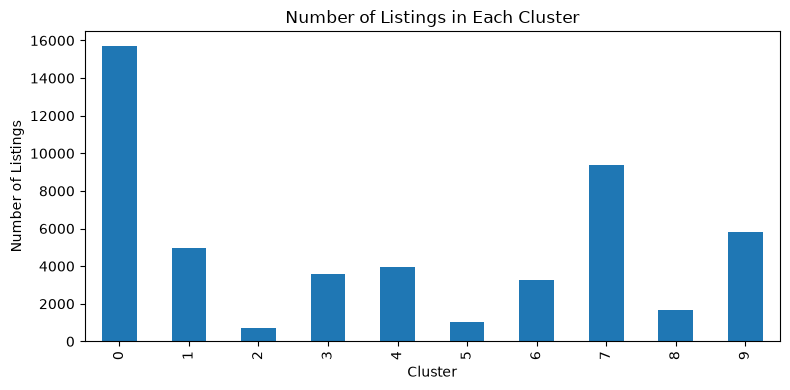

In [59]:
cluster_counts = (
    cluster_sample["cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))
cluster_counts.plot(kind="bar")

plt.title("Number of Listings in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

# Machine Learning - Task 1: Property Clustering

## Feature Selection

Since clustering is intended to support a recommender system, candidate
features are evaluated based on:

1. Relevance to user preferences
2. Data availability / missingness
3. Variability and information content
4. Redundancy with other features
5. Suitability for distance-based clustering

In [60]:
candidate_features = [
    "city_slug",
    "neighborhood_slug",
    "location_latitude",
    "location_longitude",
    "price_value",
    "land_size",
    "building_size",
    "rooms_count",
    "construction_year",
    "has_parking",
    "has_elevator",
    "has_warehouse",
    "has_balcony",
    "cat2_slug",
    "cat3_slug",
    "property_type"
]

In [61]:
feature_audit = pd.DataFrame({
    "dtype": df[candidate_features].dtypes.astype(str),
    "missing_percent": (
        df[candidate_features].isna().mean() * 100
    ).round(2),
    "unique_count": df[candidate_features].nunique(dropna=True)
})

feature_audit.sort_values("missing_percent")

,dtype,missing_percent,unique_count
city_slug,str,0.00,421
cat3_slug,str,0.00,16
cat2_slug,str,0.00,6
building_size,float64,1.96,3572
rooms_count,str,15.41,6
construction_year,str,18.42,34
has_parking,object,27.18,2
has_warehouse,object,27.18,2
location_latitude,float64,34.44,387488
location_longitude,float64,34.44,429431


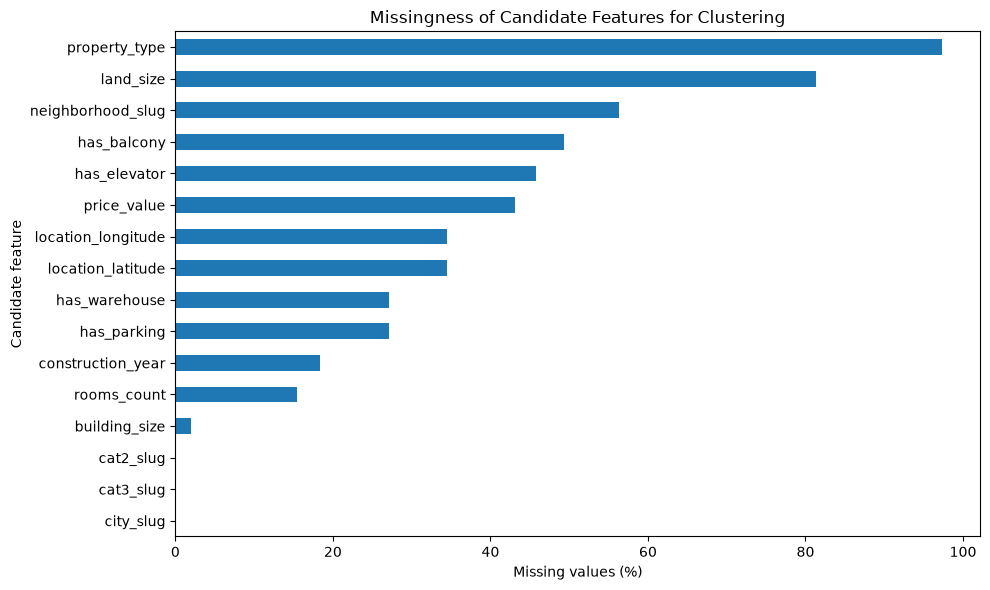

In [62]:
plt.figure(figsize=(10, 6))

(
    feature_audit["missing_percent"]
    .sort_values()
    .plot(kind="barh")
)

plt.xlabel("Missing values (%)")
plt.ylabel("Candidate feature")
plt.title("Missingness of Candidate Features for Clustering")
plt.tight_layout()
plt.show()

## UTM Zone Inspection

Before converting geographic coordinates to UTM, we inspect the
distribution of UTM zones in the dataset. Since the dataset contains
properties from different parts of Iran, forcing all coordinates into
one UTM zone may distort geographic distances.

In [63]:
geo_df = df[
    df["location_latitude"].notna() &
    df["location_longitude"].notna()
].copy()

geo_df["utm_zone"] = (
    ((geo_df["location_longitude"] + 180) // 6) + 1
).astype(int)

geo_df["utm_zone"].value_counts().sort_index()

utm_zone
37         3
38     54454
39    505055
40     89682
41      6413
43         1
Name: count, dtype: int64

In [64]:
rooms_mapping = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5
}

df["rooms_numeric"] = df["rooms_count"].map(rooms_mapping)

In [65]:
cluster_base = df[
    df["price_value"].notna() &
    (df["price_value"] > 0) &
    df["location_latitude"].notna() &
    df["location_longitude"].notna() &
    df["building_size"].notna() &
    (df["building_size"] > 0) &
    df["rooms_numeric"].notna()
].copy()

print("Usable rows:", len(cluster_base))

Usable rows: 299679


In [66]:
cluster_base["log_price"] = np.log1p(cluster_base["price_value"])
cluster_base["log_building_size"] = np.log1p(cluster_base["building_size"])

In [67]:
feature_sets = {
    "Location + Price": [
        "location_latitude",
        "location_longitude",
        "log_price"
    ],

    "Location + Price + Size": [
        "location_latitude",
        "location_longitude",
        "log_price",
        "log_building_size"
    ],

    "Location + Price + Size + Rooms": [
        "location_latitude",
        "location_longitude",
        "log_price",
        "log_building_size",
        "rooms_numeric"
    ]
}

In [68]:
comparison_sample = cluster_base.sample(
    n=min(50000, len(cluster_base)),
    random_state=42
)

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for name, features in feature_sets.items():

    X = comparison_sample[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(
        n_clusters=10,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(5000, len(X_scaled)),
        random_state=42
    )

    results.append({
        "feature_set": name,
        "n_features": len(features),
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette
    })

feature_comparison = pd.DataFrame(results)

feature_comparison

,feature_set,n_features,inertia,silhouette_score
0,Location + Price,3,20786.220546,0.422045
1,Location + Price + Size,4,49705.112372,0.309798
2,Location + Price + Size + Rooms,5,74052.256972,0.339808


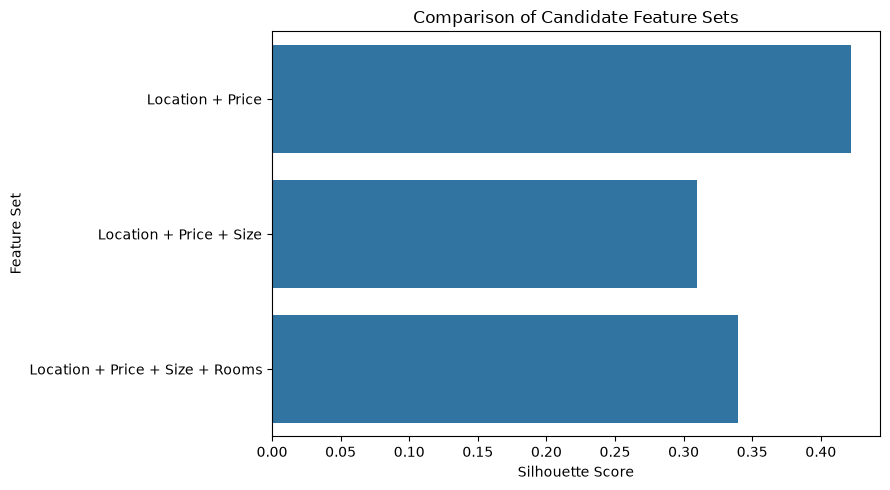

In [70]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_comparison,
    x="silhouette_score",
    y="feature_set"
)

plt.title("Comparison of Candidate Feature Sets")
plt.xlabel("Silhouette Score")
plt.ylabel("Feature Set")

plt.tight_layout()
plt.show()

In [71]:
cluster_base["utm_zone"] = (
    ((cluster_base["location_longitude"] + 180) // 6) + 1
).astype(int)

cluster_utm = cluster_base[
    cluster_base["utm_zone"] == 39
].copy()

print("Rows before zone filtering:", len(cluster_base))
print("Rows in UTM Zone 39:", len(cluster_utm))

Rows before zone filtering: 299679
Rows in UTM Zone 39: 239192


In [72]:
pip install pyproj

Note: you may need to restart the kernel to use updated packages.


In [73]:
from pyproj import Transformer

transformer = Transformer.from_crs(
    "EPSG:4326",   # WGS84 lat/lon
    "EPSG:32639",  # UTM Zone 39N
    always_xy=True
)

utm_easting, utm_northing = transformer.transform(
    cluster_utm["location_longitude"].values,
    cluster_utm["location_latitude"].values
)

cluster_utm["utm_easting"] = utm_easting
cluster_utm["utm_northing"] = utm_northing

In [74]:
cluster_utm[
    [
        "location_latitude",
        "location_longitude",
        "utm_easting",
        "utm_northing"
    ]
].head()

,location_latitude,location_longitude,utm_easting,utm_northing
7,35.729832,51.505466,545711.558185,3.954101e+06
8,35.712364,50.794781,481437.130969,3.952066e+06
10,35.778664,51.757549,568467.028494,3.959664e+06
13,32.467804,51.404095,537973.973070,3.592362e+06
24,36.387695,52.101719,598808.838769,4.027515e+06


In [75]:
final_features = [
    "utm_easting",
    "utm_northing",
    "log_price",
    "log_building_size",
    "rooms_numeric"
]

In [76]:
final_sample = cluster_utm.sample(
    n=min(50000, len(cluster_utm)),
    random_state=42
).copy()

In [77]:
X = final_sample[final_features]

In [78]:
from sklearn.preprocessing import StandardScaler

final_scaler = StandardScaler()

X_scaled = final_scaler.fit_transform(X)

In [79]:
from sklearn.cluster import KMeans

kmeans_10 = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

final_sample["cluster"] = kmeans_10.fit_predict(X_scaled)

In [80]:
final_sample["cluster"].value_counts().sort_index()

cluster
0     3534
1    18078
2     2426
3     9898
4      895
5     3900
6     1531
7      608
8     6032
9     3098
Name: count, dtype: int64

In [81]:
centers_original = final_scaler.inverse_transform(
    kmeans_10.cluster_centers_
)

centers_df = pd.DataFrame(
    centers_original,
    columns=final_features
)

centers_df["price"] = np.expm1(
    centers_df["log_price"]
)

centers_df["building_size"] = np.expm1(
    centers_df["log_building_size"]
)

centers_df

,utm_easting,utm_northing,log_price,log_building_size,rooms_numeric,price,building_size
0,289410.662999,3.622265e+06,21.678479,4.657230,2.059706,2.599225e+09,104.343843
1,531765.441441,3.959961e+06,21.986227,4.519631,1.994966,3.535877e+09,90.801727
2,641600.760419,3.252770e+06,22.020796,4.779176,2.120363,3.660246e+09,118.006268
3,517932.419127,3.938122e+06,21.583540,3.931457,0.847242,2.363809e+09,49.981226
4,483621.119931,3.809727e+06,9.736212,4.653379,1.823464,1.691832e+04,103.939024
5,355026.423013,4.123870e+06,21.758612,4.603968,2.013077,2.816082e+09,98.879854
6,526169.118836,3.879025e+06,23.400675,5.924531,4.381605,1.454736e+10,373.102807
7,463879.230804,3.825438e+06,21.346645,8.613170,0.720395,1.865220e+09,5502.667344
8,540193.308803,3.977440e+06,22.896820,5.113887,2.985075,8.789467e+09,165.315538
9,552259.894302,3.603257e+06,21.960029,4.769747,2.113944,3.444446e+09,116.889438


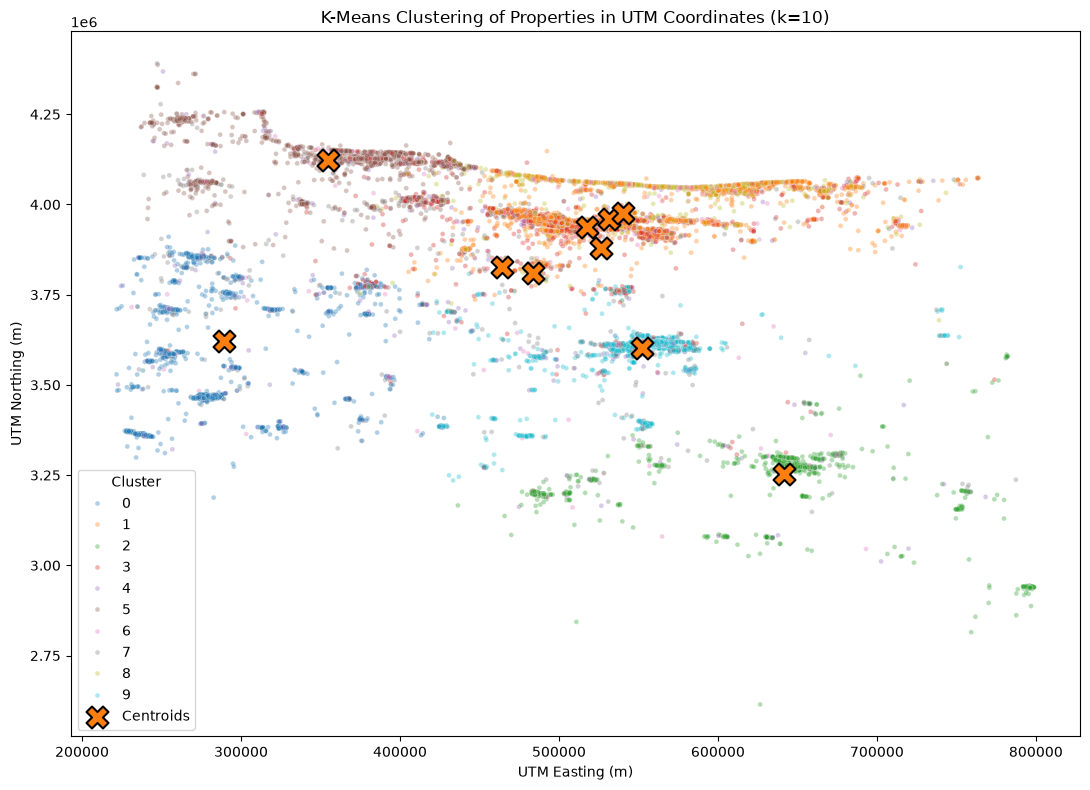

In [82]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=final_sample,
    x="utm_easting",
    y="utm_northing",
    hue="cluster",
    palette="tab10",
    s=12,
    alpha=0.35,
    legend="full"
)

plt.scatter(
    centers_df["utm_easting"],
    centers_df["utm_northing"],
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=1.5,
    label="Centroids"
)

plt.title("K-Means Clustering of Properties in UTM Coordinates (k=10)")
plt.xlabel("UTM Easting (m)")
plt.ylabel("UTM Northing (m)")

plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

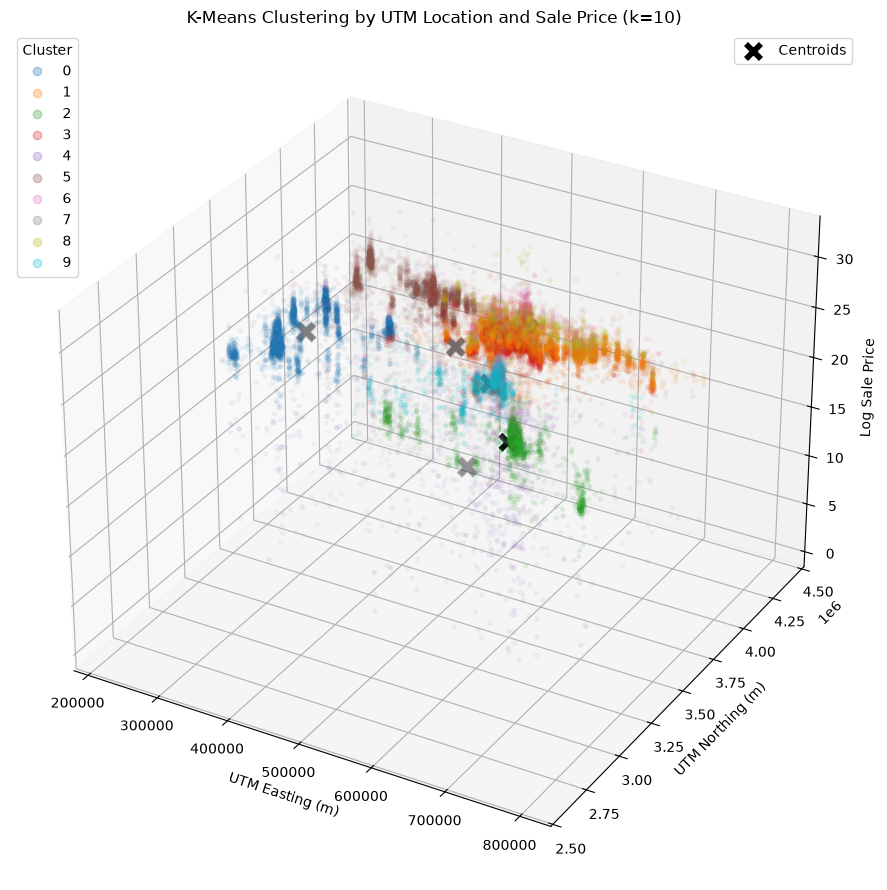

In [83]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    final_sample["utm_easting"],
    final_sample["utm_northing"],
    final_sample["log_price"],
    c=final_sample["cluster"],
    cmap="tab10",
    s=8,
    alpha=0.30
)

# Cluster centroids
ax.scatter(
    centers_df["utm_easting"],
    centers_df["utm_northing"],
    centers_df["log_price"],
    marker="X",
    s=250,
    c="black",
    edgecolors="white",
    linewidths=1.5,
    label="Centroids"
)

ax.set_xlabel("UTM Easting (m)")
ax.set_ylabel("UTM Northing (m)")
ax.set_zlabel("Log Sale Price")

ax.set_title(
    "K-Means Clustering by UTM Location and Sale Price (k=10)"
)

legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Cluster",
    loc="upper left"
)

ax.add_artist(legend1)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [84]:
cluster_profile = (
    final_sample.groupby("cluster")
    .agg(
        count=("cluster", "size"),
        median_price=("price_value", "median"),
        median_building_size=("building_size", "median"),
        median_rooms=("rooms_numeric", "median"),
        mean_utm_easting=("utm_easting", "mean"),
        mean_utm_northing=("utm_northing", "mean")
    )
)

cluster_profile

,count,median_price,median_building_size,median_rooms,mean_utm_easting,mean_utm_northing
cluster,,,,,,
0,3534,2.800000e+09,100.0,2.0,289410.662999,3.622265e+06
1,18078,3.400000e+09,89.0,2.0,531765.441441,3.959961e+06
2,2426,4.000000e+09,120.0,2.0,641600.760419,3.252770e+06
3,9898,2.300000e+09,54.0,1.0,517932.419127,3.938122e+06
4,895,1.000000e+05,100.0,2.0,483621.119931,3.809727e+06
5,3900,2.800000e+09,95.0,2.0,355026.423013,4.123870e+06
6,1531,1.300000e+10,326.0,4.0,526112.211836,3.878866e+06
7,608,2.645000e+09,3000.0,0.0,463879.230804,3.825438e+06
8,6032,8.700000e+09,155.0,3.0,540203.102609,3.977447e+06


In [85]:
cluster_profile["percentage"] = (
    cluster_profile["count"]
    / len(final_sample)
    * 100
)

cluster_profile

,count,median_price,median_building_size,median_rooms,mean_utm_easting,mean_utm_northing,percentage
cluster,,,,,,,
0,3534,2.800000e+09,100.0,2.0,289410.662999,3.622265e+06,7.068
1,18078,3.400000e+09,89.0,2.0,531765.441441,3.959961e+06,36.156
2,2426,4.000000e+09,120.0,2.0,641600.760419,3.252770e+06,4.852
3,9898,2.300000e+09,54.0,1.0,517932.419127,3.938122e+06,19.796
4,895,1.000000e+05,100.0,2.0,483621.119931,3.809727e+06,1.790
5,3900,2.800000e+09,95.0,2.0,355026.423013,4.123870e+06,7.800
6,1531,1.300000e+10,326.0,4.0,526112.211836,3.878866e+06,3.062
7,608,2.645000e+09,3000.0,0.0,463879.230804,3.825438e+06,1.216
8,6032,8.700000e+09,155.0,3.0,540203.102609,3.977447e+06,12.064


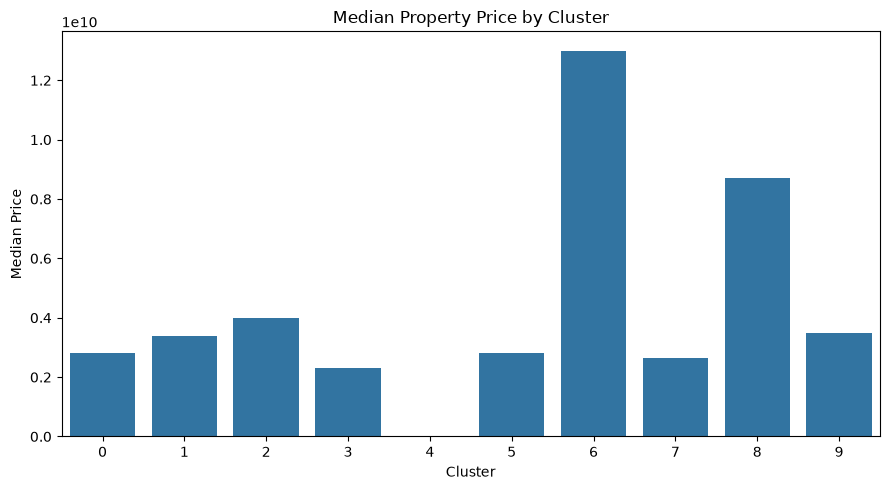

In [86]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=cluster_profile.reset_index(),
    x="cluster",
    y="median_price"
)

plt.title("Median Property Price by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Median Price")

plt.tight_layout()
plt.show()

## Task 2

In [87]:
k_sample = cluster_utm.sample(
    n=min(20000, len(cluster_utm)),
    random_state=42
).copy()

X_k = k_sample[final_features]

k_scaler = StandardScaler()
X_k_scaled = k_scaler.fit_transform(X_k)

In [88]:
k_values = range(1, 21)
wcss = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_k_scaled)
    wcss.append(model.inertia_)

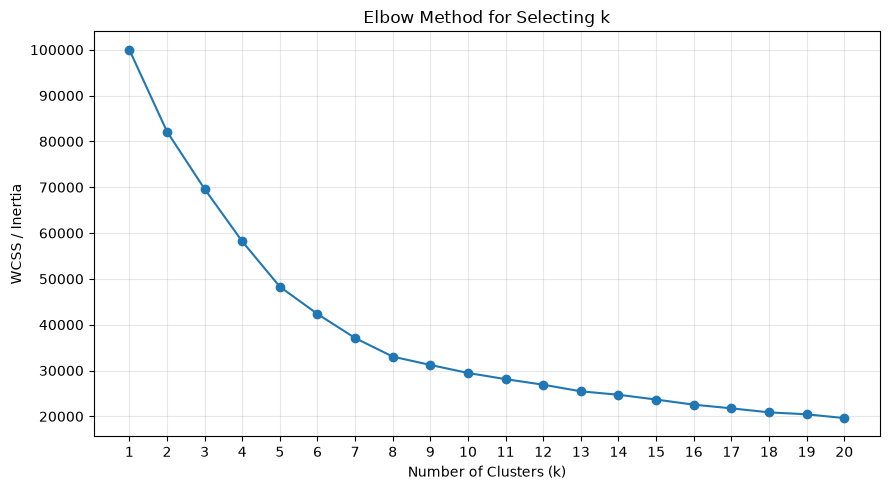

In [89]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    wcss,
    marker="o"
)

plt.xticks(range(1, 21))
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for Selecting k")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [90]:
silhouette_scores = []

for k in range(2, 21):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_k_scaled)

    score = silhouette_score(
        X_k_scaled,
        labels,
        sample_size=min(5000, len(X_k_scaled)),
        random_state=42
    )

    silhouette_scores.append(score)

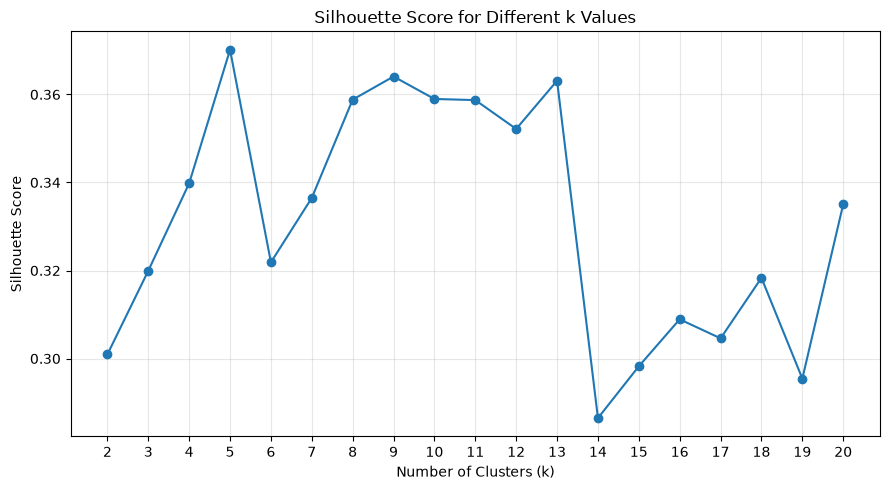

In [91]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(2, 21),
    silhouette_scores,
    marker="o"
)

plt.xticks(range(2, 21))
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k Values")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [92]:
k_evaluation = pd.DataFrame({
    "k": range(2, 21),
    "wcss": wcss[1:],
    "silhouette_score": silhouette_scores
})

k_evaluation

,k,wcss,silhouette_score
0,2,82147.126547,0.300944
1,3,69619.850084,0.319946
2,4,58178.365057,0.339814
3,5,48286.962767,0.370158
4,6,42342.709280,0.321862
5,7,37087.406154,0.336501
6,8,33038.887252,0.358821
7,9,31219.504675,0.364077
8,10,29472.565831,0.358975
9,11,28119.742358,0.358718


## Reforms


## Mentor Feedback Revision 1 — All-Zone Clustering and Sample-to-Full Error Validation

The previous prototype was restricted to UTM Zone 39. In this revision, all usable
records from all geographic zones are retained.

Because native UTM coordinates from different zones do not share the same coordinate
origin, they should not be directly mixed in a single Euclidean K-Means space.
Therefore:

1. Each property keeps its correct native UTM zone and native UTM coordinates.
2. For global K-Means clustering, all locations are projected into one common metric
   coordinate system centered on the dataset.
3. K-Means is trained on a representative subsample and then evaluated on the entire
   usable dataset.

To evaluate whether the subsample is representative, we compare the average
within-cluster squared error:

Average Error = WCSS / Number of Samples

between the training sample and the full dataset.

If these two errors are close, the cluster structure learned from the sample
generalizes well to the full dataset.

In [ ]:
import numpy as np
import pandas as pd

from pyproj import CRS, Transformer

cluster_all = cluster_base.copy()

cluster_all["utm_zone"] = (
    ((cluster_all["location_longitude"] + 180) // 6) + 1
).astype(int)

print("Total usable rows:", len(cluster_all))
print("\nRows per UTM zone:")
print(cluster_all["utm_zone"].value_counts().sort_index())

Total usable rows: 299679

Rows per UTM zone:
utm_zone
38     23499
39    239192
40     34849
41      2139
Name: count, dtype: int64


### Native UTM Coordinates for All Zones

Each property is converted to the UTM coordinate system corresponding to its own
geographic zone.

These native UTM coordinates are retained for geographic interpretation and
visualization. They are not directly mixed across zones for global K-Means because
different UTM zones use different coordinate origins.

In [94]:
cluster_all["utm_easting_native"] = np.nan
cluster_all["utm_northing_native"] = np.nan

for zone in sorted(cluster_all["utm_zone"].unique()):

    mask = cluster_all["utm_zone"] == zone

    # Iran is in the Northern Hemisphere:
    # EPSG 326xx = WGS84 / UTM zone xxN
    epsg_code = 32600 + int(zone)

    zone_transformer = Transformer.from_crs(
        "EPSG:4326",
        f"EPSG:{epsg_code}",
        always_xy=True
    )

    east, north = zone_transformer.transform(
        cluster_all.loc[mask, "location_longitude"].values,
        cluster_all.loc[mask, "location_latitude"].values
    )

    cluster_all.loc[mask, "utm_easting_native"] = east
    cluster_all.loc[mask, "utm_northing_native"] = north

cluster_all[
    [
        "location_latitude",
        "location_longitude",
        "utm_zone",
        "utm_easting_native",
        "utm_northing_native"
    ]
].head()

,location_latitude,location_longitude,utm_zone,utm_easting_native,utm_northing_native
7,35.729832,51.505466,39,545711.558185,3.954101e+06
8,35.712364,50.794781,39,481437.130969,3.952066e+06
10,35.778664,51.757549,39,568467.028494,3.959664e+06
12,36.321831,59.524502,40,726621.357899,4.022603e+06
13,32.467804,51.404095,39,537973.973070,3.592362e+06


### Common Metric Coordinate System for Global K-Means

To cluster properties from all UTM zones simultaneously, geographic coordinates must
exist in one continuous metric coordinate system.

An Azimuthal Equidistant projection centered on the geographic center of the usable
dataset is used. This keeps all locations in the same coordinate system measured in
meters and avoids the discontinuity between UTM zones.

In [ ]:
# Geographic center of the usable dataset
center_lat = cluster_all["location_latitude"].median()
center_lon = cluster_all["location_longitude"].median()

print("Projection center:")
print("Latitude :", center_lat)
print("Longitude:", center_lon)

common_metric_crs = CRS.from_proj4(
    f"+proj=aeqd "
    f"+lat_0={center_lat} "
    f"+lon_0={center_lon} "
    f"+datum=WGS84 "
    f"+units=m "
    f"+no_defs"
)

global_transformer = Transformer.from_crs(
    "EPSG:4326",
    common_metric_crs,
    always_xy=True
)

geo_x, geo_y = global_transformer.transform(
    cluster_all["location_longitude"].values,
    cluster_all["location_latitude"].values
)

cluster_all["geo_x_m"] = geo_x
cluster_all["geo_y_m"] = geo_y

Projection center:
Latitude : 35.72534942626953
Longitude: 51.3345832824707


In [96]:
all_zone_features = [
    "geo_x_m",
    "geo_y_m",
    "log_price",
    "log_building_size",
    "rooms_numeric"
]

cluster_all[all_zone_features].describe()

,geo_x_m,geo_y_m,log_price,log_building_size,rooms_numeric
count,2.996790e+05,2.996790e+05,299679.000000,299679.000000,299679.000000
mean,2.069927e+04,-5.960839e+04,21.716590,4.649580,1.973672
std,2.740652e+05,2.426669e+05,2.164872,0.826390,0.922077
min,-7.313405e+05,-1.339599e+06,0.693147,0.693147,0.000000
25%,-4.606931e+04,-3.808686e+04,21.282882,4.290459,1.000000
50%,0.000000e+00,4.517918e+01,21.886417,4.564348,2.000000
75%,3.833424e+04,8.351412e+04,22.563815,4.912655,2.000000
max,1.111131e+06,5.250238e+05,32.236191,16.118096,5.000000


### Sample-to-Full K-Means Generalization Error

A K-Means model is trained on a 50,000-row subsample.

For each value of k from 1 to 20, two errors are calculated:

- Sample Error: average squared distance of the training sample to its assigned centroid.
- Full-Data Error: average squared distance of every usable property to the centroids
  learned from the sample.

Both errors are normalized by the number of observations, making them directly
comparable even though the datasets have different sizes.

A small gap between the two curves indicates that the sample is representative and
that the learned cluster structure generalizes to the full dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Training subsample
sample_size = min(50000, len(cluster_all))

train_sample = cluster_all.sample(
    n=sample_size,
    random_state=42
).copy()

X_sample_df = train_sample[all_zone_features]
X_full_df = cluster_all[all_zone_features]

# Fit scaler ONLY on the training sample
all_zone_scaler = StandardScaler()

X_sample_scaled = all_zone_scaler.fit_transform(X_sample_df)
X_full_scaled = all_zone_scaler.transform(X_full_df)

print("Training sample size:", len(X_sample_scaled))
print("Full dataset size:", len(X_full_scaled))

Training sample size: 50000
Full dataset size: 299679


In [ ]:
generalization_results = []
models_by_k = {}

for k in range(1, 21):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Train only on the sample
    sample_labels = model.fit_predict(X_sample_scaled)

    models_by_k[k] = model


    sample_wcss = model.inertia_

    sample_avg_error = (
        sample_wcss / len(X_sample_scaled)
    )


    full_labels = model.predict(X_full_scaled)

    assigned_centers = model.cluster_centers_[full_labels]

    squared_distances = np.sum(
        (X_full_scaled - assigned_centers) ** 2,
        axis=1
    )

    full_avg_error = squared_distances.mean()

    # Generalization gap
    gap = full_avg_error - sample_avg_error

    gap_percent = (
        abs(gap) / sample_avg_error * 100
    )

    generalization_results.append({
        "k": k,
        "sample_wcss": sample_wcss,
        "sample_avg_error": sample_avg_error,
        "full_avg_error": full_avg_error,
        "error_gap": gap,
        "gap_percent": gap_percent
    })

generalization_df = pd.DataFrame(generalization_results)

generalization_df

,k,sample_wcss,sample_avg_error,full_avg_error,error_gap,gap_percent
0,1,250000.000000,5.000000,4.980253,-0.019747,0.394942
1,2,206811.016780,4.136220,4.114176,-0.022045,0.532967
2,3,175187.288442,3.503746,3.498906,-0.004840,0.138131
3,4,148422.816415,2.968456,2.968954,0.000498,0.016781
4,5,121700.473833,2.434009,2.412964,-0.021045,0.864638
5,6,106082.200047,2.121644,2.110349,-0.011295,0.532390
6,7,91798.746595,1.835975,1.829401,-0.006573,0.358037
7,8,85078.723897,1.701574,1.697879,-0.003696,0.217201
8,9,78646.578979,1.572932,1.571098,-0.001833,0.116547
9,10,74431.063694,1.488621,1.483200,-0.005421,0.364193


### Sample vs Full-Data Error Comparison

The following visualization compares the normalized clustering error on the training
sample and the full dataset.

The percentage gap is also displayed as a generalization indicator.

A good candidate k should provide reasonably low clustering error while maintaining
a small sample-to-full generalization gap.

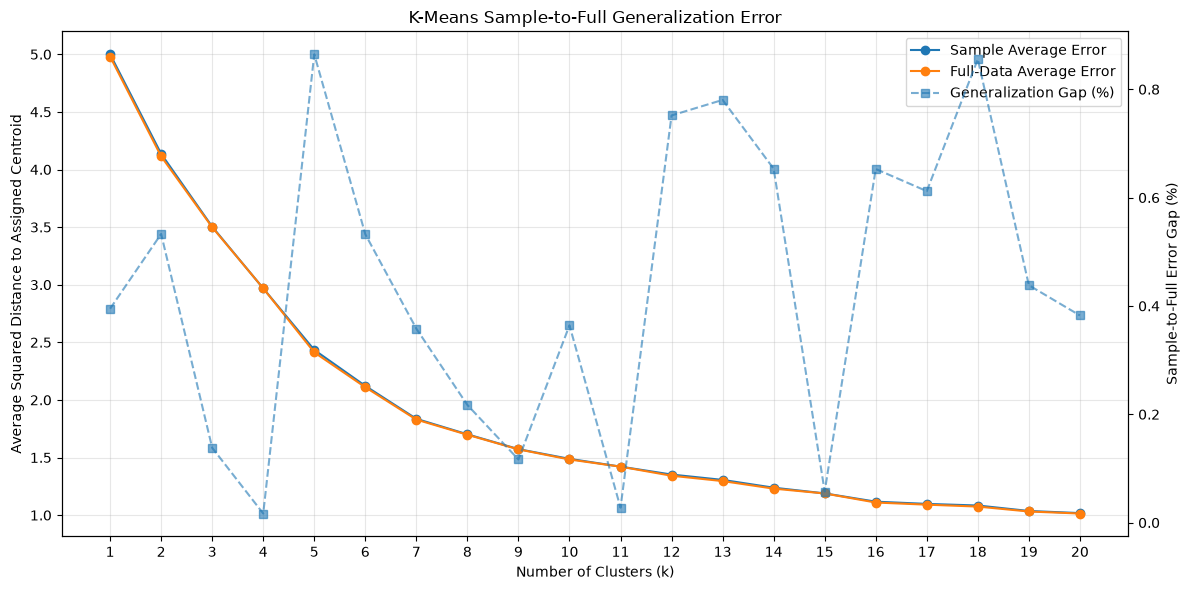

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# Sample vs full average error
line1 = ax1.plot(
    generalization_df["k"],
    generalization_df["sample_avg_error"],
    marker="o",
    label="Sample Average Error"
)

line2 = ax1.plot(
    generalization_df["k"],
    generalization_df["full_avg_error"],
    marker="o",
    label="Full-Data Average Error"
)

ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Average Squared Distance to Assigned Centroid")
ax1.set_xticks(range(1, 21))
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

line3 = ax2.plot(
    generalization_df["k"],
    generalization_df["gap_percent"],
    marker="s",
    linestyle="--",
    alpha=0.6,
    label="Generalization Gap (%)"
)

ax2.set_ylabel("Sample-to-Full Error Gap (%)")

# Combined legend
lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="best"
)

plt.title(
    "K-Means Sample-to-Full Generalization Error"
)

plt.tight_layout()
plt.show()

## Mentor Feedback Revision 2 — Enhanced Elbow Analysis with WCSS Slope

WCSS always decreases as the number of clusters increases. Therefore, the optimal
number of clusters cannot be selected simply by choosing the smallest WCSS.

To make the elbow easier to identify, the change in WCSS between consecutive values
of k is also calculated.

Because Δk = 1, the change in WCSS directly represents the slope between consecutive
points.

The relative WCSS reduction is plotted together with the original Elbow curve.
The elbow is expected near the point where the improvement begins to decrease
substantially.

In [ ]:
k_values_all = generalization_df["k"].to_numpy()
wcss_values_all = generalization_df["sample_wcss"].to_numpy()

# Raw slope: ΔWCSS / Δk
# Since Δk = 1, this is simply ΔWCSS
wcss_slope = np.diff(wcss_values_all)

wcss_reduction = -wcss_slope

relative_reduction = (
    wcss_reduction /
    wcss_values_all[:-1]
) * 100

slope_df = pd.DataFrame({
    "from_k": k_values_all[:-1],
    "to_k": k_values_all[1:],
    "delta_wcss": wcss_slope,
    "wcss_reduction": wcss_reduction,
    "relative_reduction_percent": relative_reduction
})

slope_df

,from_k,to_k,delta_wcss,wcss_reduction,relative_reduction_percent
0,1,2,-43188.983220,43188.983220,17.275593
1,2,3,-31623.728338,31623.728338,15.291124
2,3,4,-26764.472027,26764.472027,15.277634
3,4,5,-26722.342582,26722.342582,18.004201
4,5,6,-15618.273786,15618.273786,12.833371
5,6,7,-14283.453452,14283.453452,13.464515
6,7,8,-6720.022698,6720.022698,7.320386
7,8,9,-6432.144918,6432.144918,7.560227
8,9,10,-4215.515285,4215.515285,5.360075
9,10,11,-3368.485301,3368.485301,4.525644


### Elbow Plot with Relative WCSS Reduction

The original WCSS curve is shown together with the percentage reduction obtained by
adding each new cluster.

Large percentage reductions indicate that an additional cluster provides substantial
improvement.

When these reductions begin to fall and remain relatively small, adding more clusters
provides diminishing returns. This transition provides a clearer visual indication of
the elbow.

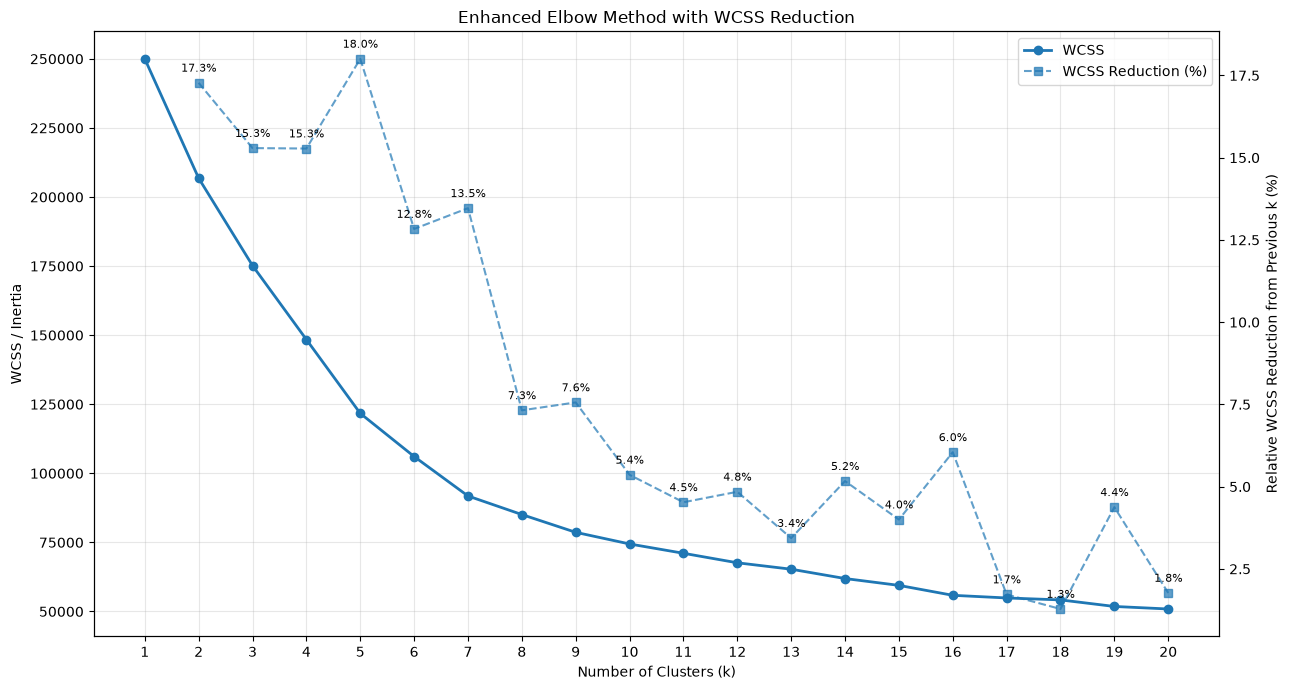

In [101]:
fig, ax1 = plt.subplots(figsize=(13, 7))

# Main WCSS curve
ax1.plot(
    k_values_all,
    wcss_values_all,
    marker="o",
    linewidth=2,
    label="WCSS"
)

ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("WCSS / Inertia")
ax1.set_xticks(range(1, 21))
ax1.grid(alpha=0.3)

# Secondary axis = relative WCSS reduction
ax2 = ax1.twinx()

ax2.plot(
    k_values_all[1:],
    relative_reduction,
    marker="s",
    linestyle="--",
    alpha=0.7,
    label="WCSS Reduction (%)"
)

ax2.set_ylabel(
    "Relative WCSS Reduction from Previous k (%)"
)

# Show reduction percentage over every point
for k, reduction in zip(
    k_values_all[1:],
    relative_reduction
):
    ax2.annotate(
        f"{reduction:.1f}%",
        (k, reduction),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title(
    "Enhanced Elbow Method with WCSS Reduction"
)

plt.tight_layout()
plt.show()

### National K-Means Cluster Map — All Geographic Zones

The previous visualization used only UTM Zone 39 and therefore represented only a
subset of the geographic coverage.

In this revision, all usable geographic zones are included. Since native UTM
coordinates from different zones cannot be directly combined in one Euclidean plane,
a common metric coordinate system is used for global clustering and visualization.

The resulting scatter plot should preserve the overall geographic shape of Iran while
showing the K-Means cluster assignment and cluster centroids.

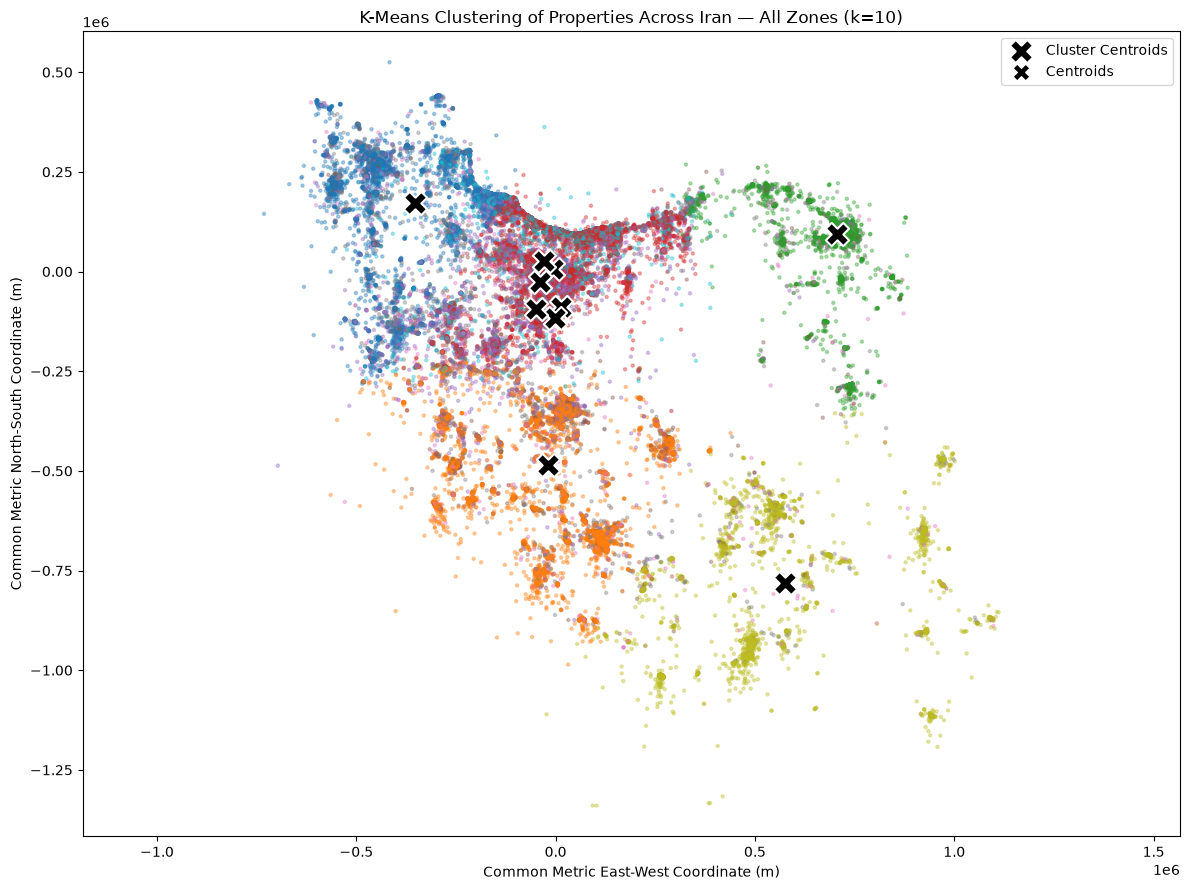

In [102]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Features using ALL geographic zones
map_features = [
    "geo_x_m",
    "geo_y_m",
    "log_price",
    "log_building_size",
    "rooms_numeric"
]

# Use the full usable dataset
X_all = cluster_all[map_features]

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

# Task 1 requires k = 10
kmeans_all_10 = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

cluster_all["cluster_k10"] = kmeans_all_10.fit_predict(X_all_scaled)

# Convert centroids back to original feature scale
centers_original = scaler_all.inverse_transform(
    kmeans_all_10.cluster_centers_
)

centers_all = pd.DataFrame(
    centers_original,
    columns=map_features
)

# Plot
plt.figure(figsize=(12, 9))

scatter = plt.scatter(
    cluster_all["geo_x_m"],
    cluster_all["geo_y_m"],
    c=cluster_all["cluster_k10"],
    cmap="tab10",
    s=5,
    alpha=0.35
)

plt.scatter(
    centers_all["geo_x_m"],
    centers_all["geo_y_m"],
    marker="X",
    s=280,
    c="black",
    edgecolors="white",
    linewidths=1.5,
    label="Cluster Centroids"
)

plt.xlabel("Common Metric East-West Coordinate (m)")
plt.ylabel("Common Metric North-South Coordinate (m)")

plt.title(
    "K-Means Clustering of Properties Across Iran — All Zones (k=10)"
)

plt.legend(*scatter.legend_elements(), title="Cluster", loc="upper left")
plt.scatter([], [], marker="X", s=150, c="black",
            edgecolors="white", label="Centroids")
plt.legend(loc="best")

plt.axis("equal")
plt.tight_layout()
plt.show()